In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns

In [2]:
ccolors = plt.get_cmap('tab10')

# dispersal rates

## true trees only

In [3]:
def exp_est_disp_plot(SIGMAdisps, nreps, string, filename=''):
    
    xmin,xmax=0,1
    SIGMAmate = 0.5
    
    xyss = []
    for SIGMAdisp in SIGMAdisps:
        xys = []
        for nrep in nreps:
            mle = np.load(string %(SIGMAdisp, nrep))
#             x = SIGMAdisp**2 + SIGMAmate**2/2 #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
            xys.append(mle[0]**2)
            xys.append(mle[1]**2)
#             xys.append([mle[0]**2,mle[1]**2])
        xyss.append(xys)
    xyss = np.array(xyss)
    
    fig, ax = plt.subplots(1,1, figsize=(5,5))

#     ax.scatter(xyss[:,0], xyss[:,1], label='x', alpha=0.5, marker='x', color=ccolors(0))
#     ax.scatter(xyss[:,0], xyss[:,2], label='y', alpha=0.5, marker='o', color=ccolors(0))
#     ax.boxplot(np.transpose(xyss), positions=[SIGMAdisp**2 + SIGMAmate**2/2 for SIGMAdisp in SIGMAdisps], patch_artist=True, widths=0.1, vert=True)
    ax.violinplot(np.transpose(xyss), positions=[SIGMAdisp**2 + SIGMAmate**2/2 for SIGMAdisp in SIGMAdisps], widths=0.1, showmeans=True, showextrema=True)
    ax.plot([xmin,xmax],[xmin,xmax], c='k')
    
    ax.set_xlabel('expected dispersal rate')
    ax.set_ylabel('estimated dispersal rate')
    ax.set_xlim(xmin,xmax)
    ax.set_ylim(xmin,xmax)

    if filename!='':
        plt.savefig(filename)

    plt.show()

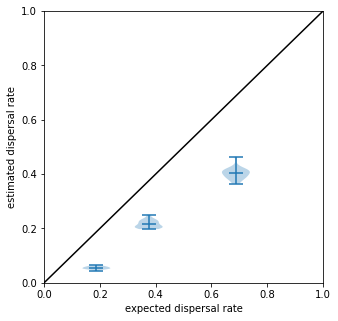

In [4]:
SIGMAdisps = [0.25,0.5,0.75]
nreps = range(10)
string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_NonetCutoff_mle-dispersal.npy'

exp_est_disp_plot(SIGMAdisps, nreps, string, filename='plots/disp-true.pdf')

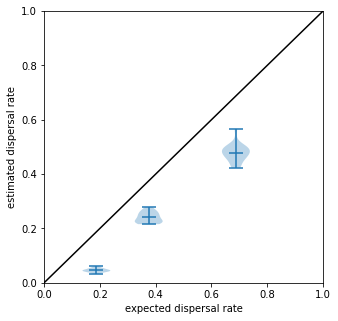

In [5]:
SIGMAdisps = [0.25,0.5,0.75]
nreps = range(10)
string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_1000tCutoff_mle-dispersal.npy'

exp_est_disp_plot(SIGMAdisps, nreps, string, filename='plots/disp-true-1000T.pdf')

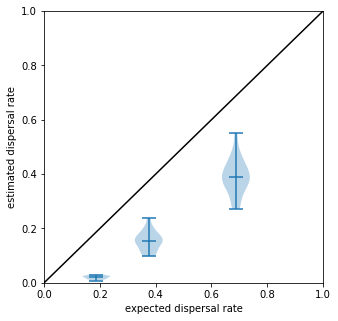

In [7]:
SIGMAdisps = [0.25,0.5,0.75]
nreps = range(10)
string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_100d_50k_2G_100treeskip_100tCutoff_mle-dispersal.npy'

exp_est_disp_plot(SIGMAdisps, nreps, string, filename='plots/disp-true-100T.pdf')

## true vs inferred trees

In [28]:
def true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=None):

    # expected = [SIGMAdisp**2 for SIGMAdisp in SIGMAdisps] #ignores fact that higher variance to father
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2) for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2)**0.5 for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    
    fig, axs = plt.subplots(1, 1, figsize=(5,5))

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(true_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    true_mless = np.array(mless)

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(inferred_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    inf_mless = np.array(mless)

    axs.plot([0,xmax], [0,xmax], c='k', zorder=0)
    for i,ex in enumerate(expected):
#         axs.scatter(true_mless[i,:,0]**2, inf_mless[i,:,0]**2, label='$\sigma^2=$%s, x' %ex, alpha=0.5, color=ccolors(i), marker='x')
#         axs.scatter(true_mless[i,:,1]**2, inf_mless[i,:,1]**2, label='$\sigma^2=$%s, y' %ex, alpha=0.5, color=ccolors(i), marker='o')
        axs.scatter(true_mless[i,:,0], inf_mless[i,:,0], label='$\sigma^2=$%s, x' %ex, alpha=0.5, color=ccolors(i), marker='x')
        axs.scatter(true_mless[i,:,1], inf_mless[i,:,1], label='$\sigma^2=$%s, y' %ex, alpha=0.5, color=ccolors(i), marker='o')
        axs.scatter(ex, ex, marker='*')
    # axs.scatter(true_mless[:,:,0], inf_mless[:,:,0], label='x', alpha=0.5)
    # axs.scatter(true_mless[:,:,1], inf_mless[:,:,1], label='y', alpha=0.5)
    axs.set_xlabel(r'$\widehat{\sigma}$, true trees')
    axs.set_ylabel(r'$\widehat{\sigma}$, inferred trees')
#     plt.legend()
    plt.show()

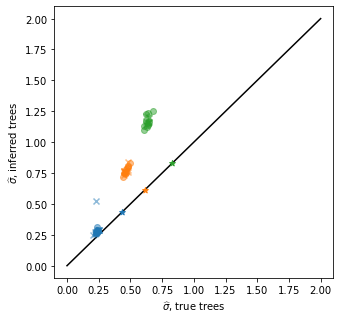

In [32]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 'None'
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_blup-dispersal.npy'

true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=2)

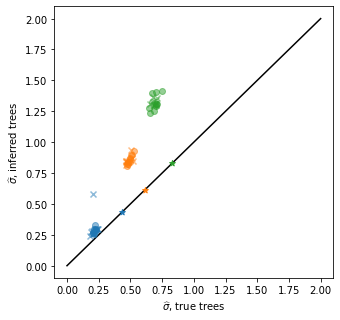

In [33]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 1000
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_blup-dispersal.npy'

true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=2)

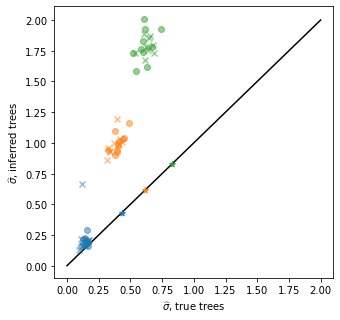

In [34]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 100
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_blup-dispersal.npy'

true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=2)

# ancestor locations

In [3]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_40000MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip'
filename = prefix + '_anc-locs.npy'
real_anc_locs = np.load(filename)
filename = prefix + '_NonetCutoff_ancestor-locations.npy'
true_anc_locs = np.load(filename)
filename = prefix + '_NonetCutoff_ancestor-variances.npy'
true_anc_vars = np.load(filename)

In [4]:
retain_gens = range(0,1001,100)
sigma = np.array([[0.5**2,0],[0,0.5**2]])

## single lineages

In [5]:
def _plot_cov_ellipse(cov, pos, nstd=2, ax=None, **kwargs):
    """
    Plots an `nstd` sigma error ellipse based on the specified covariance
    matrix (`cov`). Additional keyword arguments are passed on to the 
    ellipse patch artist.

    Parameters
    ----------
        cov : The 2x2 covariance matrix to base the ellipse on
        pos : The location of the center of the ellipse. Expects a 2-element
            sequence of [x0, y0].
        nstd : The radius of the ellipse in numbers of standard deviations.
            Defaults to 2 standard deviations.
        ax : The axis that the ellipse will be plotted on. Defaults to the 
            current axis.
        Additional keyword arguments are pass on to the ellipse patch.

    Returns
    -------
        A matplotlib ellipse artist
    """
    def _eigsorted(cov):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        return vals[order], vecs[:,order]

    if ax is None:
        ax = plt.gca()

    vals, vecs = _eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height are "full" widths, not radius
    width, height = 2 * nstd * np.sqrt(vals)
    ellip = patches.Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)

    ax.add_artist(ellip)
    return ellip

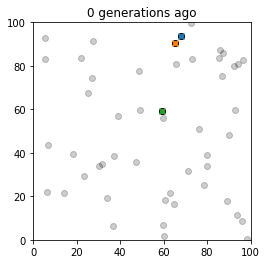

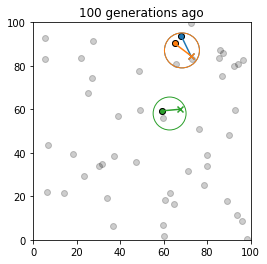

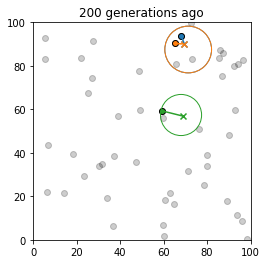

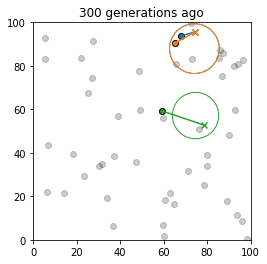

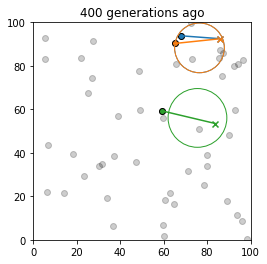

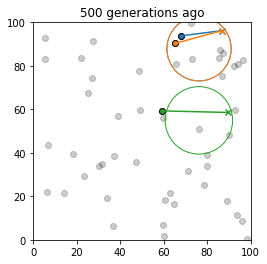

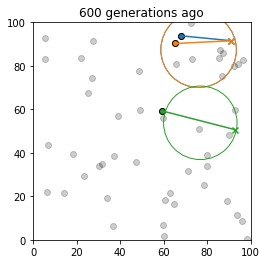

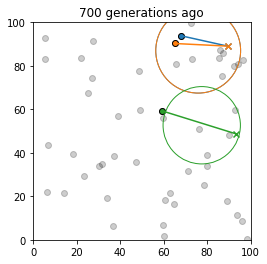

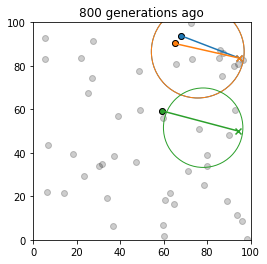

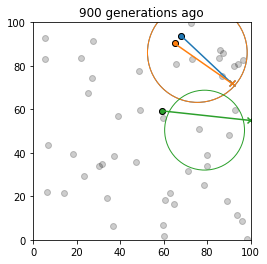

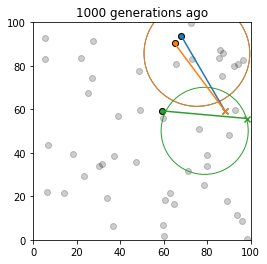

In [154]:
locus=0
samples=[2,16,4]
sample_colors = [ccolors(i) for i in range(len(samples))]

for i,t in enumerate(retain_gens):

    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    
    ax.scatter(real_anc_locs[0,:,0,0], real_anc_locs[0,:,0,1], color='k', alpha=0.1) #all samples
    
    for sample, sample_color in zip(samples, sample_colors):
        
        ax.scatter(real_anc_locs[locus,sample,0,0], real_anc_locs[locus,sample,0,1], color=sample_color, label=sample, edgecolors='k') #sample location
        ax.scatter(real_anc_locs[locus,sample,i,0], real_anc_locs[locus,sample,i,1], color=sample_color, marker='x') #ancestor location
        ax.plot([real_anc_locs[locus,sample,0,0],real_anc_locs[locus,sample,i,0]], [real_anc_locs[locus,sample,0,1],real_anc_locs[locus,sample,i,1]], color=sample_color) #connnect
        _plot_cov_ellipse(sigma*true_anc_vars[locus,sample,i,0], [true_anc_locs[locus,sample,i,0], true_anc_locs[locus,sample,i,1]], 
                          nstd=1.96, fill=False, color=sample_color) #95% CI
        
    ax.set_xlim(0,100)
    ax.set_ylim(0,100)
    ax.set_title('%d generations ago' %t)
#     ax.legend()

    plt.savefig('plots/single-lineages-%dt.pdf' %t)
    
    plt.show()

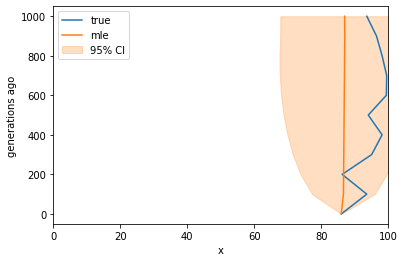

In [7]:
axis=0
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(real_anc_locs[0,0,:,axis], retain_gens, label='true')
ax.plot(true_anc_locs[0,0,:,axis], retain_gens, label='mle')
ax.fill_betweenx(retain_gens, 
                 true_anc_locs[0,0,:,axis] - 1.96*(0.5**2*true_anc_vars[0,0,:,0])**0.5, true_anc_locs[0,0,:,axis] + 1.96*(0.5**2*true_anc_vars[0,0,:,0])**0.5, 
                 color=ccolors(1), alpha=0.25 ,label='95% CI')
# ax.scatter(true_anc_locs[0,0,i,0], true_anc_locs[0,0,i,1], label='inferred')
# ax.scatter(real_anc_locs[0,0,i,0], real_anc_locs[0,0,i,1], label='true')
# _plot_cov_ellipse(sigma*true_anc_vars[0,0,i,0], [true_anc_locs[0,0,i,0], true_anc_locs[0,0,i,1]], nstd=1.96, fill=False, color=ccolors(0))
ax.set_xlim(0,100)
# ax.set_ylim(0,100)
# ax.set_title('%d generations ago' %t)
ax.legend()
if axis==0:
    ax.set_xlabel('x')
else:
    ax.set_xlabel('y')
ax.set_ylabel('generations ago')
plt.show()

In [274]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_100d_50k_2G_100treeskip'

sse_mle = np.zeros(11)
sse_sample = np.zeros(11)
sse_mean_sample = np.zeros(11)
n = 0
for rep in nreps:
    
    prefix_rep = prefix %rep
    
    filename = prefix_rep + '_anc-locs.npy'
    real_anc_locs = np.load(filename)
    
    filename = prefix_rep + '_NonetCutoff_ancestor-locations.npy'
    true_anc_locs = np.load(filename)

    sse_mle += np.sum(np.sum((real_anc_locs - true_anc_locs)**2, axis=-1), axis=(0,1))

    sample_locs = np.repeat(real_anc_locs[:,:,0,:], 11, axis=-2).reshape(real_anc_locs.shape) #locations of samples
    sse_sample += np.sum(np.sum((real_anc_locs - sample_locs)**2, axis=-1), axis=(0,1))
    
    mean_loc = np.repeat(np.mean(real_anc_locs[:,:,0,:],axis=1), 11*100, axis=-2).reshape(real_anc_locs.shape) #mean sample location
    sse_mean_sample += np.sum(np.sum((real_anc_locs - mean_loc)**2, axis=-1), axis=(0,1))

    n += len(real_anc_locs)*len(real_anc_locs[0])
    
rmse_mle = (sse_mle/n)**0.5
rmse_sample = (sse_sample/n)**0.5
rmse_mean_sample = (sse_mean_sample/n)**0.5

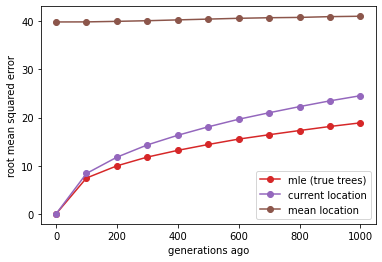

In [275]:
plt.plot(range(0,1001,100), rmse_mle, marker='o', label='mle (true trees)', color=ccolors(3))
plt.plot(range(0,1001,100), rmse_sample, marker='o', label='current location', color=ccolors(4))
plt.plot(range(0,1001,100), rmse_mean_sample, marker='o', label='mean location', color=ccolors(5))

plt.xlabel('generations ago')
plt.ylabel('root mean squared error')
plt.legend()

plt.savefig('plots/rmse-single-lineages.pdf')

plt.show()

## ancestor clouds

/tmp/ipykernel_79327/373071132.py:14: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=true_anc_locs[:,sample,i,0], y=true_anc_locs[:,sample,i,1], ax=ax, zorder=0, color=sample_color) #inferred
/tmp/ipykernel_79327/373071132.py:16: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=real_anc_locs[:,sample,i,0], y=real_anc_locs[:,sample,i,1], ax=ax, zorder=0, alpha=0.1, color='k') #real


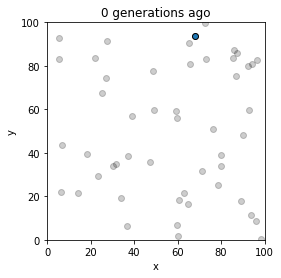

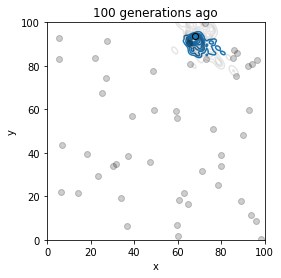

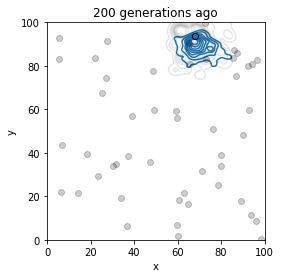

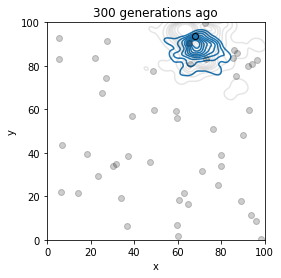

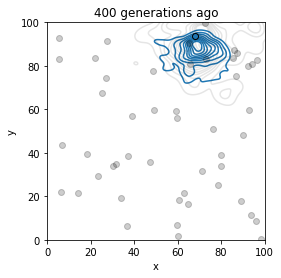

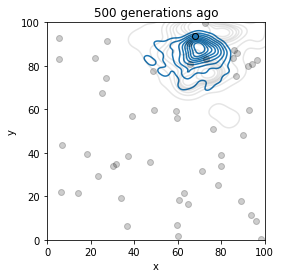

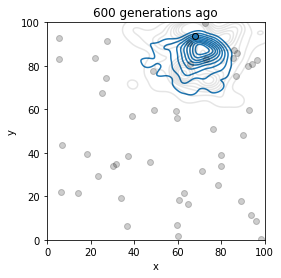

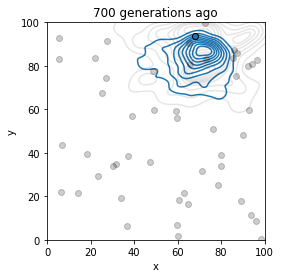

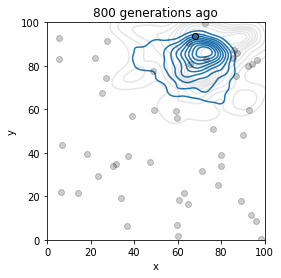

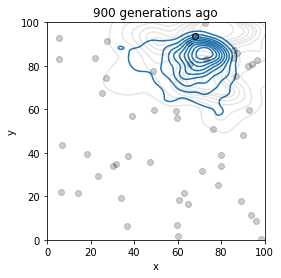

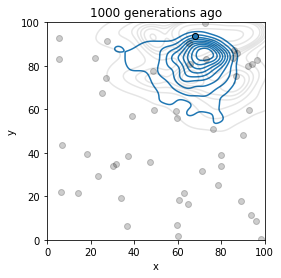

In [155]:
# sample=4
# sample_color = ccolors(2)
sample=2
sample_color = ccolors(0)

for i,t in enumerate(retain_gens):
    
    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    
    ax.scatter(real_anc_locs[0,:,0,0], real_anc_locs[0,:,0,1], color='k', alpha=0.1) #all samples
    ax.scatter(real_anc_locs[0,sample,0,0], real_anc_locs[0,sample,0,1], color=sample_color, zorder=1, edgecolors='k') #focal samples

    sns.kdeplot(x=true_anc_locs[:,sample,i,0], y=true_anc_locs[:,sample,i,1], ax=ax, zorder=0, color=sample_color) #inferred
#     ax.scatter(real_anc_locs[:,sample,i,0], real_anc_locs[:,sample,i,1], color=ccolors(1))
    sns.kdeplot(x=real_anc_locs[:,sample,i,0], y=real_anc_locs[:,sample,i,1], ax=ax, zorder=0, alpha=0.1, color='k') #real
    
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.title('%d generations ago' %t)
    plt.xlabel('x')
    plt.ylabel('y')
    # plt.legend()
    
    plt.savefig('plots/ancestor-clouds-%dt.pdf' %t)
    
    plt.show()

In [276]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_0.5SIGMAmate_0.5SIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_100d_50k_2G_100treeskip'

sse_mle = np.zeros(11)
sse_sample = np.zeros(11)
sse_mean_sample = np.zeros(11)
n = 0
for rep in nreps:
    
    prefix_rep = prefix %rep
    
    filename = prefix_rep + '_anc-locs.npy'
    real_anc_locs = np.load(filename)
    
    filename = prefix_rep + '_NonetCutoff_ancestor-locations.npy'
    true_anc_locs = np.load(filename)

    sse_mle += np.sum(np.sum((np.mean(real_anc_locs, axis=0) - np.mean(true_anc_locs, axis=0))**2, axis=-1), axis=0)

    sample_locs = np.repeat(real_anc_locs[:,:,0,:], 11, axis=-2).reshape(real_anc_locs.shape) #locations of samples
    sse_sample += np.sum(np.sum((np.mean(real_anc_locs,axis=0) - np.mean(sample_locs,axis=0))**2, axis=-1), axis=0)
    
    mean_loc = np.repeat(np.mean(real_anc_locs[:,:,0,:],axis=1), 11*100, axis=-2).reshape(real_anc_locs.shape) #mean sample location
    sse_mean_sample += np.sum(np.sum((np.mean(real_anc_locs,axis=0) - np.mean(mean_loc,axis=0))**2, axis=-1), axis=0)

    n += len(real_anc_locs[0])
    
rmse_mle = (sse_mle/n)**0.5
rmse_sample = (sse_sample/n)**0.5
rmse_mean_sample = (sse_mean_sample/n)**0.5

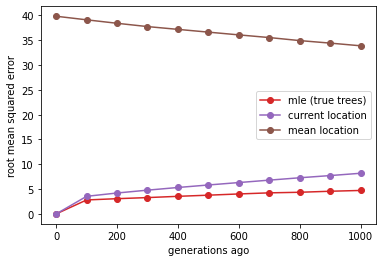

In [277]:
plt.plot(range(0,1001,100), rmse_mle, marker='o', label='mle (true trees)', color=ccolors(3))
plt.plot(range(0,1001,100), rmse_sample, marker='o', label='current location', color=ccolors(4))
plt.plot(range(0,1001,100), rmse_mean_sample, marker='o', label='mean location', color=ccolors(5))

plt.xlabel('generations ago')
plt.ylabel('root mean squared error')
plt.legend()

plt.savefig('plots/rmse-ancestor-clouds.pdf')

plt.show()

# ----------------- old below here -------------------

low, even with 100 gen cutoff, but this is consistent with Ianni-Ravn et al Fig 6 and Fig S2 (https://www.biorxiv.org/content/10.1101/2023.03.27.534388v3.full) and Fig 3D in https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008561

note that we expect strong boundary effects when a lineage can cross the habitat within the time cutoff, $\sigma^2 t > W^2$ (eg, Wilkins 2004, https://academic.oup.com/genetics/article/168/4/2227/6059415). So with $W=50$ and $t=100$, we expect to underestimate dispersal whenever $\sigma^2>W^2/t=25$. we're clearly seeing an effect much earlier than this. though we also have to consider the effect of local density-dependence (but this didnt seem to do much in Ianni-Ravn et al).

why so low? let's check our method does ok when we actually simulate brownian motion

In [11]:
import msprime
ts = msprime.sim_ancestry(50) #make a tree
ts

In [12]:
from utils import get_shared_times
stss = []
for i,tree in enumerate(ts.trees()):
    if i%int(100) == 0:
        sts = get_shared_times(tree, ts.samples()) #get shared times between all pairs of samples
        stss.append(sts)

In [13]:
sigma = 0.5
SIGMA = np.array([[sigma**2,0],[0,sigma**2]]) #choose dispersal rate
locations = np.random.multivariate_normal([0]*200, np.kron(stss[0],SIGMA)).reshape(100,2) #give locations according to brownian motion

In [38]:
# pre-processing
tCutoff = None
from utils import chop_shared_times, center_shared_times
stss_inv = []
smplsss = []
for sts in stss:
    # chop
    sts_chopped, smpls = chop_shared_times(sts, tCutoff=tCutoff) #shared times and samples of each subtree
    sts_inv = []
    smplss = []
    # process subtrees
    for st,sm in zip(sts_chopped, smpls):
        stc = center_shared_times(st) #mean center
        stc_inv = np.linalg.inv(stc) #invert
        sts_inv.append(stc_inv)
        smplss.append(sm) #samples
    stss_inv.append(sts_inv)
    smplsss.append(smplss)
#mean centered and inverted shared time matrices
stss_mc_inv = stss_inv
stss_mc_inv = np.expand_dims(stss_mc_inv, axis=1)
#subtree samples
smplss = smplsss
smplss = np.expand_dims(smplss, axis=1)

In [39]:
#dispersal
from spacetrees import mle_dispersal
# find parameter estimates
mle = mle_dispersal(locations=locations, shared_times_inverted=stss_mc_inv, samples=smplss,
                    important=False, BLUP=True)
mle

number of loci: 1 
number of trees per locus: 1 
number of samples: 100 
number of spatial dimensions: 2

preparing locations
and finding best linear unbiased predictor (BLUP) of dispersal rate


100%|██████████| 1/1 [00:00<00:00, 292.71it/s]

BLUP dispersal rate:
 [[ 0.25926704 -0.01007217]
 [-0.01007217  0.18094474]]


[0.5091827198240851, 0.42537599676106097, -0.04650249459686031]

hmm, so the method is working, at least with 1 tree and no cutoff. 

now let's just duplicate the tree, to see if the number of loci is an issue

In [40]:
ntrees = 10
stss_mc_inv_rep = stss_mc_inv.repeat(ntrees, axis=0)
smplss_rep = smplss.repeat(ntrees, axis=0)

In [41]:
# find parameter estimates
mle = mle_dispersal(locations=locations, shared_times_inverted=stss_mc_inv_rep, samples=smplss_rep,
                    important=False, BLUP=True)
mle

number of loci: 10 
number of trees per locus: 1 
number of samples: 100 
number of spatial dimensions: 2

preparing locations
and finding best linear unbiased predictor (BLUP) of dispersal rate


100%|██████████| 10/10 [00:00<00:00, 539.61it/s]

BLUP dispersal rate:
 [[ 0.25926704 -0.01007217]
 [-0.01007217  0.18094474]]


[0.5091827198240851, 0.42537599676106097, -0.046502494596860317]

so not an issue with number of loci. so let's cut into subtrees, to see if having subtrees is an issue

In [42]:
np.max(stss)

3.3087279626655723

In [66]:
tCutoff = 2
from utils import chop_shared_times, center_shared_times
stss_inv = []
smplsss = []
for sts in stss:
    # chop
    sts_chopped, smpls = chop_shared_times(sts, tCutoff=tCutoff) #shared times and samples of each subtree
    sts_inv = []
    smplss = []
    # process subtrees
    for st,sm in zip(sts_chopped, smpls):
        stc = center_shared_times(st) #mean center
        stc_inv = np.linalg.inv(stc) #invert
        sts_inv.append(stc_inv)
        smplss.append(sm) #samples
    stss_inv.append(sts_inv)
    smplsss.append(smplss)
stss_mc_inv = [stss_inv]
smplss = [smplsss]

In [69]:
mle = mle_dispersal(locations=locations, shared_times_inverted=stss_mc_inv, samples=smplss,
                    important=False, BLUP=True)
mle

number of loci: 1 
number of trees per locus: 1 
number of samples: 100 
number of spatial dimensions: 2

preparing locations
and finding best linear unbiased predictor (BLUP) of dispersal rate


100%|██████████| 1/1 [00:00<00:00, 369.15it/s]

BLUP dispersal rate:
 [[ 0.26140005 -0.0098066 ]
 [-0.0098066   0.18252642]]


[0.5112729670344272, 0.4272311071685076, -0.04489549792634577]

that also seems fine :|

anything fishy about the tree sequences?

In [5]:
ts_file = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_2.0K_50W_0.5SIGMAcomp_0.5SIGMAmate_1.75SIGMAdisp_0selfing_20000MAXT_7nrep_5000Ne_1e-08U_50k_2G.trees'

In [6]:
import tskit

In [7]:
ts = tskit.load(ts_file)

In [8]:
ts

In [15]:
alive = [i.id for i in ts.individuals()]
alive_locs = ts.individual_locations[alive]
d=10
((alive_locs[:, 0] - 50/2)**2 + (alive_locs[:, 1] - 50/2)**2)**0.5 < d

array([False, False, False, False, False,  True, False, False, False,
        True,  True, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False,  True, False, False,  True, False, False,
       False, False, False, False, False])

In [23]:
ts_file = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_2.0K_50W_0.5SIGMAcomp_0.5SIGMAmate_1.75SIGMAdisp_0selfing_20000MAXT_7nrep.trees'
ts = tskit.load(ts_file)
ts

In [26]:
ts_file = 'slim_test/data/sim_100000000L_1e-08RBP_2.0LAMBDA_2.0K_100W_0.7071067811865476SIGMAcomp_0.7071067811865476SIGMAmate_0.5SIGMAdisp_0selfing_20000MAXT_7nrep.trees'
ts = tskit.load(ts_file)
ts

In [27]:
ts.individual_locations

array([[66.06390685, 89.22414785,  0.        ],
       [67.17625968, 89.59845788,  0.        ],
       [66.75309384, 88.24220555,  0.        ],
       ...,
       [22.69342484, 67.6799178 ,  0.        ],
       [25.66152914, 67.03672537,  0.        ],
       [23.20722864, 66.46718881,  0.        ]])

In [39]:
[i.id for i in ts.individuals() if ((i.location[0] - 100/2)**2 + (i.location[1] - 100/2)**2)**0.5 < 10]

[2193,
 2194,
 2195,
 2196,
 3112,
 3227,
 3228,
 3229,
 3239,
 3242,
 3243,
 3244,
 3245,
 3246,
 3247,
 3248,
 3249,
 3250,
 3251,
 3252,
 3253,
 3254,
 3255,
 3256,
 3257,
 3258,
 3259,
 3260,
 3261,
 3262,
 3263,
 3265,
 3276,
 3277,
 4033,
 4034,
 4035,
 4036,
 4037,
 4038,
 4039,
 4040,
 4041,
 4042,
 4043,
 4044,
 4045,
 4046,
 4047,
 4048,
 4049,
 4050,
 4051,
 4052,
 4053,
 4054,
 4055,
 4056,
 4057,
 4058,
 4064,
 4065,
 4066,
 4067,
 4068,
 4069,
 4070,
 4071,
 4072,
 4073,
 4074,
 4117,
 4118,
 4121,
 4122,
 4123,
 4124,
 4125,
 4126,
 4128,
 4129,
 4130,
 4131,
 4132,
 4133,
 4136,
 4137,
 4138,
 4139,
 4140,
 4141,
 4142,
 4143,
 4144,
 4145,
 4146,
 4147,
 4148,
 4149,
 4150,
 4151,
 4152,
 4153,
 4154,
 4155,
 4156,
 5784,
 5785,
 5786,
 5787,
 5794,
 7004,
 7005,
 7006,
 7007,
 7008,
 7009,
 7010,
 7011,
 7012,
 7013,
 7014,
 7015,
 7016,
 7017,
 7018,
 7019,
 7020,
 7021,
 7022,
 7023,
 7024,
 7025,
 7026,
 7027,
 7028,
 7029,
 7030,
 7031,
 7032,
 7033,
 7034,
 7035,